In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(20640, 9)


In [6]:
X = df.drop("Price", axis=1)

y = df["Price"]

print("Features and Target Created")

Features and Target Created


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Done")

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Train-Test Split Done
Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [10]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression Trained")

Linear Regression Trained


In [11]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Ridge Regression Trained")

Ridge Regression Trained


In [12]:
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("Decision Tree Trained")

Decision Tree Trained


In [13]:
def evaluate(y_true, y_pred, model_name):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(model_name)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print()

In [14]:
evaluate(
    y_test,
    lr_pred,
    "Linear Regression"
)

evaluate(
    y_test,
    ridge_pred,
    "Ridge Regression"
)

evaluate(
    y_test,
    tree_pred,
    "Decision Tree"
)

Linear Regression
RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508

Ridge Regression
RMSE: 0.7455567442814778
R2 Score: 0.5758157428913686

Decision Tree
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081



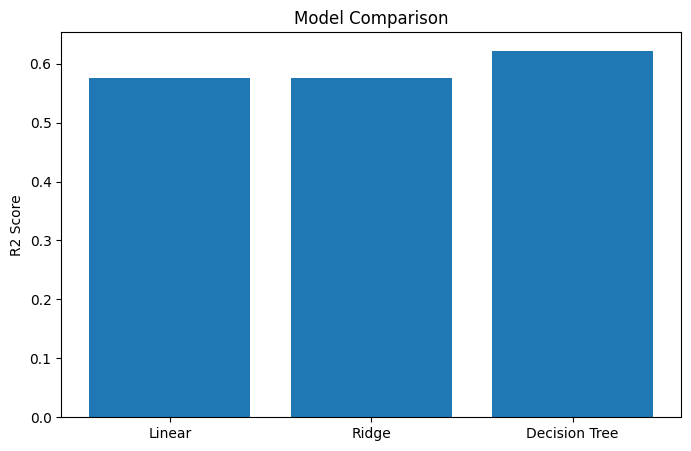

In [15]:
models = [
    "Linear",
    "Ridge",
    "Decision Tree"
]

scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, ridge_pred),
    r2_score(y_test, tree_pred)
]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

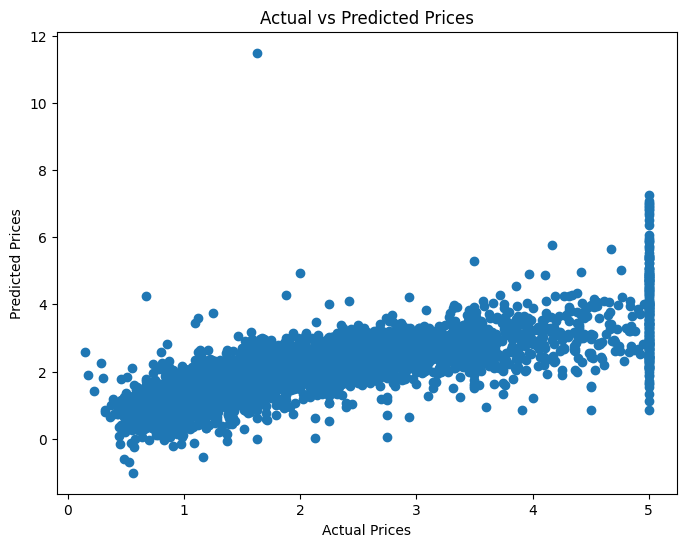

In [16]:
best_pred = ridge_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_pred
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [17]:
print("Best Model: Ridge Regression")

Best Model: Ridge Regression
